# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and PCA
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

In [1]:
# Add scripts directory to path
import sys
from pathlib import Path

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported successfully")

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All modules imported successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
PCA_COMPONENTS = cfg.PCA_COMPONENTS  # 50
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = 40

# Data paths (relative to data directory)
NEWS_PATH = "../data/german_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 5.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)

✓ Using device: Apple MPS GPU
  Optimal batch size: 128


## 4. Stage 1: Data Ingestion

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=100,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (100, 4)
Energy telemetry shape: (7462, 5)
Baseline feature frame: (7270, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 0.74s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +14.4 MB read, +2.0 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Data loaded successfully
  News articles: 100
  Energy records: 7462
  Master records: 7270


### Inspect Data

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    2971
 1.0    2859
 0.0    1440
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    40.866575
 1.0    39.325997
 0.0    19.807428
Name: proportion, dtype: float64


## 5. Stage 2: News Processing - Topic Classification

In [6]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    embedding_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        batch_size=device_config['optimal_batch_size'],
        model_name=cfg.ZEROSHOT_MODEL,
    )

news_df = embedding_results['news_df']

print(f"\n✓ Topic classification completed")
print(f"  Device used: {embedding_results['hf_device']}")
print(f"  Batch size: {embedding_results['batch_size']}")


[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use mps


Processing 100 texts with batch_size=128
Classification completed: 100 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot         46
die Großhandelspreise für Erdgas steigen                                           15
sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage                11
geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken     8
die Stromerzeugung aus Wind und Sonne steigt                                        6
der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot         4
der Stromverbrauch in Deutschland steigt                                            4
der Stromverbrauch in Deutschland fällt                                             2
die Stromerzeugung aus Wind und Sonne fällt                                         2
die Großhandelspreise für Erdgas fallen           

## 6. Stage 2B: Sentence Embeddings

In [7]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting
Loaded embeddings from cache (../outputs/.cache/embeddings/news_embeddings.parquet)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 0.08s
  CPU usage: 52.5% • IO wait: 0.00%
  Disk Δ: +6.4 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Embeddings computed
  Embedding dimension: 384


## 7. Stage 3: Feature Engineering - Time-Decay Aggregation

In [8]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        n_components=PCA_COMPONENTS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 9 parameter combinations...
[1/9] lookback=168h, decay_lambda=0.01
Embedding reduction backend: umap-learn
[2/9] lookback=168h, decay_lambda=0.05
Embedding reduction backend: umap-learn
[3/9] lookback=168h, decay_lambda=0.1
Embedding reduction backend: umap-learn
[4/9] lookback=336h, decay_lambda=0.01
Embedding reduction backend: umap-learn
[5/9] lookback=336h, decay_lambda=0.05
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.05_reduction.parquet)
[6/9] lookback=336h, decay_lambda=0.1
Embedding reduction backend: umap-learn
[7/9] lookback=504h, decay_lambda=0.01
Embedding reduction backend: umap-learn
[8/9] lookback=504h, decay_lambda=0.05
Embedding reduction backend: umap-learn
[9/9] lookback=504h, decay_lambda=0.1
Embedding reduction backend: umap-learn
[Stage ✅] Stage 3A: Time-Decay Feature Precomputation — completed in 43.42s
  CPU usage: 62.5% • 

In [9]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        dataset_prefix="td_dataset",
    )

sample_params_key = next(iter(preprocessed_datasets))
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Prepared datasets: {len(preprocessed_datasets)}")
print(
    f"  Sample dataset: {sample_dataset['dataset_name']} -> "
    f"train={len(sample_dataset['train_df'])}, "
    f"val={len(sample_dataset['val_df'])}, "
    f"test={len(sample_dataset['test_df'])}"
)


[Stage ⏳] Stage 3B: Dataset Assembly — starting
[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.03s
  CPU usage: 96.2% • IO wait: 0.00%
  Disk Δ: +0.1 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset assembly complete
  Prepared datasets: 9
  Sample dataset: td_dataset_lw168_dl0.01 -> train=5089, val=1454, test=727


## 8. Stage 3C: Dataset Scaling & Summary

In [10]:
with profiling.StageProfiler("Stage 3C: Dataset Scaling", device_config):
    preprocessed_datasets = fe.scale_preprocessed_datasets(preprocessed_datasets)

sample_dataset = preprocessed_datasets[sample_params_key]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"\n✓ Dataset scaling complete")
print(f"  Scaled news features per dataset: {len(scaled_news_features)}")
print(f"  Sample scaled features: {scaled_news_features[:5]}")


[Stage ⏳] Stage 3C: Dataset Scaling — starting
[Stage ✅] Stage 3C: Dataset Scaling — completed in 0.21s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +0.1 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset scaling complete
  Scaled news features per dataset: 61
  Sample scaled features: ['die Großhandelspreise für Erdgas steigen_scaled', 'Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot_scaled', 'sinkende Zinsen oder nachlassende Inflation beruhigen die Marktlage_scaled', 'der Stromverbrauch in Deutschland fällt_scaled', 'der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot_scaled']


## 9. Stage 3D: Feature Selection with RidgeCV

In [11]:
# Baseline (price + temporal) features stay fixed across datasets
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168",
    "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# News feature definitions come from the assembled datasets
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline features: {len(baseline_features)}")
print(f"  Topic features: {len(topic_features)}")
print(f"  Embedding features: {len(embedding_features)}")
print(f"  Total news features: {len(news_features)}")

with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_3_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_3_combinations:
    best_params_key = top_3_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(
        f"\n✓ Top parameter combination: {best_dataset['dataset_name']} "
        f"(lookback={top_3_combinations[0]['lookback_window']}h, "
        f"lambda={top_3_combinations[0]['decay_lambda']})"
    )
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline features: 13
  Topic features: 11
  Embedding features: 50
  Total news features: 61

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 9 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   9 | elapsed:   10.5s remaining:   36.8s
[Parallel(n_jobs=-1)]: Done   3 out of   9 | elapsed:   10.5s remaining:   21.1s
[Parallel(n_jobs=-1)]: Done   4 out of   9 | elapsed:   10.5s remaining:   13.2s
[Parallel(n_jobs=-1)]: Done   5 out of   9 | elapsed:   10.6s remaining:    8.5s
[Parallel(n_jobs=-1)]: Done   6 out of   9 | elapsed:   10.6s remaining:    5.3s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:   10.6s remaining:    3.0s


TOP 3 PARAMETER COMBINATIONS:
1. dataset=td_dataset_lw504_dl0.01 | lookback=504h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.440 | Val Macro-F1=0.333
2. dataset=td_dataset_lw336_dl0.01 | lookback=336h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.431 | Val Macro-F1=0.320
3. dataset=td_dataset_lw168_dl0.05 | lookback=168h | lambda=0.05 | alpha=1000.0000 | Val Accuracy=0.428 | Val Macro-F1=0.320
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 11.13s
  CPU usage: 92.6% • IO wait: 0.00%
  Disk Δ: +182.6 MB read, +293.8 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Top parameter combination: td_dataset_lw504_dl0.01 (lookback=504h, lambda=0.01)


[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:   11.1s finished


## 10. Stage 3E: Summarise Ridge Results

In [12]:
if top_3_combinations:
    top_3_summary = pd.DataFrame([
        {
            "dataset_name": res["dataset_name"],
            "lookback_window": res["lookback_window"],
            "decay_lambda": res["decay_lambda"],
            "alpha": res["best_alpha"],
            "val_accuracy": res["val_accuracy"],
            "val_macro_f1": res["val_macro_f1"],
        }
        for res in top_3_combinations
    ])
    display(top_3_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,td_dataset_lw504_dl0.01,504,0.01,1000.0,0.440165,0.332889
1,td_dataset_lw336_dl0.01,336,0.01,1000.0,0.430536,0.320371
2,td_dataset_lw168_dl0.05,168,0.05,1000.0,0.427785,0.319901


## 11. Stage 4: Model Training - XGBoost with Random Search

**Note:** This section demonstrates XGBoost training with hyperparameter tuning. Adjust `n_iter` and CV parameters based on your computational resources.

In [13]:
from sklearn.metrics import accuracy_score, f1_score

with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    if top_3_combinations:
        xgb_candidates = top_3_combinations
    else:
        print("⚠ RidgeCV did not yield candidates; falling back to sample dataset.")
        xgb_candidates = [
            {
                "params_key": sample_params_key,
                "dataset_name": sample_dataset["dataset_name"],
                "lookback_window": sample_params_key[0],
                "decay_lambda": sample_params_key[1],
            }
        ]

    xgb_tuning_runs: list[dict[str, object]] = []
    xgb_best_models: dict[tuple[int, float], object] = {}
    xgb_feature_columns: dict[tuple[int, float], list[str]] = {}

    for rank, result in enumerate(xgb_candidates, start=1):
        params_key = result["params_key"]
        dataset = preprocessed_datasets[params_key]

        data_dict = {
            "train_df": dataset["train_df"],
            "scaled_news_features": dataset["scaled_news_features"],
        }

        search, feature_columns = model_utils.run_xgb_random_search(
            data_dict=data_dict,
            baseline_features=baseline_features,
            target_column=cfg.TARGET_COLUMN,
            param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
            n_iter=XGB_RANDOM_SEARCH_ITERS,
            random_state=cfg.RANDOM_STATE,
            n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
            step_size=cfg.DEFAULT_EXPANDING_STEP,
            min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
            device_config=device_config,
        )

        best_estimator = search.best_estimator_
        val_df = dataset["val_df"]
        X_val = val_df[feature_columns].fillna(0)
        y_val_binary = model_utils.map_target_to_binary(val_df[cfg.TARGET_COLUMN].astype(int))
        val_proba = best_estimator.predict_proba(X_val)[:, 1]
        val_pred_binary = (val_proba >= 0.5).astype(int)
        val_accuracy = accuracy_score(y_val_binary, val_pred_binary)
        val_macro_f1 = f1_score(y_val_binary, val_pred_binary, average="macro", zero_division=0)

        run_summary = {
            "rank": rank,
            "params_key": params_key,
            "dataset_name": dataset["dataset_name"],
            "lookback_window": result.get("lookback_window", params_key[0]),
            "decay_lambda": result.get("decay_lambda", params_key[1]),
            "best_cv_macro_f1": search.best_score_,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1,
            "best_params": search.best_params_,
            "feature_columns": feature_columns,
            "search": search,
        }

        xgb_tuning_runs.append(run_summary)
        xgb_best_models[params_key] = best_estimator
        xgb_feature_columns[params_key] = feature_columns

        print(
            f"#{rank} {dataset['dataset_name']} → "
            f"CV F1={search.best_score_:.3f}, "
            f"Val Acc={val_accuracy:.3f}, "
            f"Val Macro-F1={val_macro_f1:.3f}"
        )

if xgb_tuning_runs:
    best_xgb_run = max(
        xgb_tuning_runs,
        key=lambda r: (r["best_cv_macro_f1"], r["val_macro_f1"]),
    )
    best_xgb_params_key = best_xgb_run["params_key"]
    best_xgb_model = xgb_best_models[best_xgb_params_key]
    best_xgb_feature_columns = xgb_feature_columns[best_xgb_params_key]
    best_dataset = preprocessed_datasets[best_xgb_params_key]

    print(
        "\n✓ Selected XGBoost dataset "
        f"{best_xgb_run['dataset_name']} (lookback={best_xgb_run['lookback_window']}h, "
        f"lambda={best_xgb_run['decay_lambda']})"
    )
    print(f"  Best CV macro-F1: {best_xgb_run['best_cv_macro_f1']:.3f}")
    print(f"  Validation macro-F1: {best_xgb_run['val_macro_f1']:.3f}")
else:
    best_xgb_run = None
    best_xgb_params_key = None
    best_xgb_model = None
    best_xgb_feature_columns = []
    print("\n⚠ XGBoost tuning did not produce any runs.")


[Stage ⏳] Stage 4: XGBoost Random Search — starting
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:34] WARNING: /Users/runner/work/xgboost/xgboost/src/lear

#1 td_dataset_lw504_dl0.01 → CV F1=0.819, Val Acc=0.661, Val Macro-F1=0.577
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:42] WARNING: /Users/runner/work/xgboost/xgboost/src/lear

#2 td_dataset_lw336_dl0.01 → CV F1=0.798, Val Acc=0.651, Val Macro-F1=0.591
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [21:47:51] WARNING: /Users/runner/work/xgboost/xgboost/src/lear

#3 td_dataset_lw168_dl0.05 → CV F1=0.640, Val Acc=0.651, Val Macro-F1=0.591
[Stage ✅] Stage 4: XGBoost Random Search — completed in 25.78s
  CPU usage: 89.7% • IO wait: 0.00%
  Disk Δ: +529.6 MB read, +572.5 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Selected XGBoost dataset td_dataset_lw504_dl0.01 (lookback=504h, lambda=0.01)
  Best CV macro-F1: 0.819
  Validation macro-F1: 0.577


## 12. Stage 5: Model Evaluation

In [14]:
from sklearn.metrics import classification_report

if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

# Use the dataset associated with the selected XGBoost run
test_dataset = best_dataset
X_test = test_dataset["test_df"][best_xgb_feature_columns].fillna(0)
y_test_raw = test_dataset["test_df"][cfg.TARGET_COLUMN].astype(int)
y_test_binary = model_utils.map_target_to_binary(y_test_raw)

y_pred_proba = best_xgb_model.predict_proba(X_test)
y_pred_binary = (y_pred_proba[:, 1] >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test_binary, y_pred_binary)

print(f"\n✓ XGBoost Test Evaluation")
print(f"  Test Accuracy (binary target): {test_accuracy:.4f}")
print("\nClassification Report (binary target):")
print(classification_report(y_test_binary, y_pred_binary, target_names=["Non-positive", "Positive"]))


✓ XGBoost Test Evaluation
  Test Accuracy (binary target): 0.5516

Classification Report (binary target):
              precision    recall  f1-score   support

Non-positive       0.61      0.75      0.67       443
    Positive       0.38      0.25      0.30       284

    accuracy                           0.55       727
   macro avg       0.50      0.50      0.49       727
weighted avg       0.52      0.55      0.53       727



## 13. Visualizations

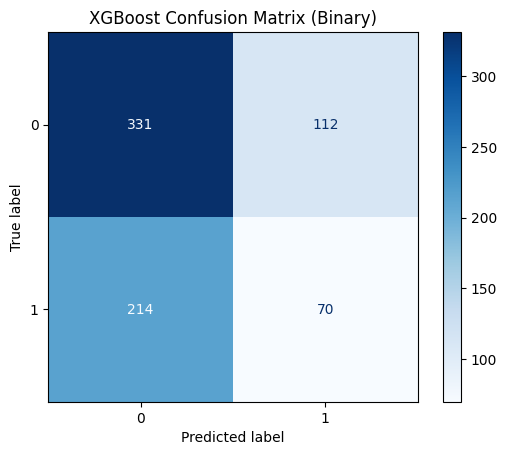

In [15]:
# Confusion matrix (binary target)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix (Binary)')
plt.show()

/Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology_refactored/scripts/visualization.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


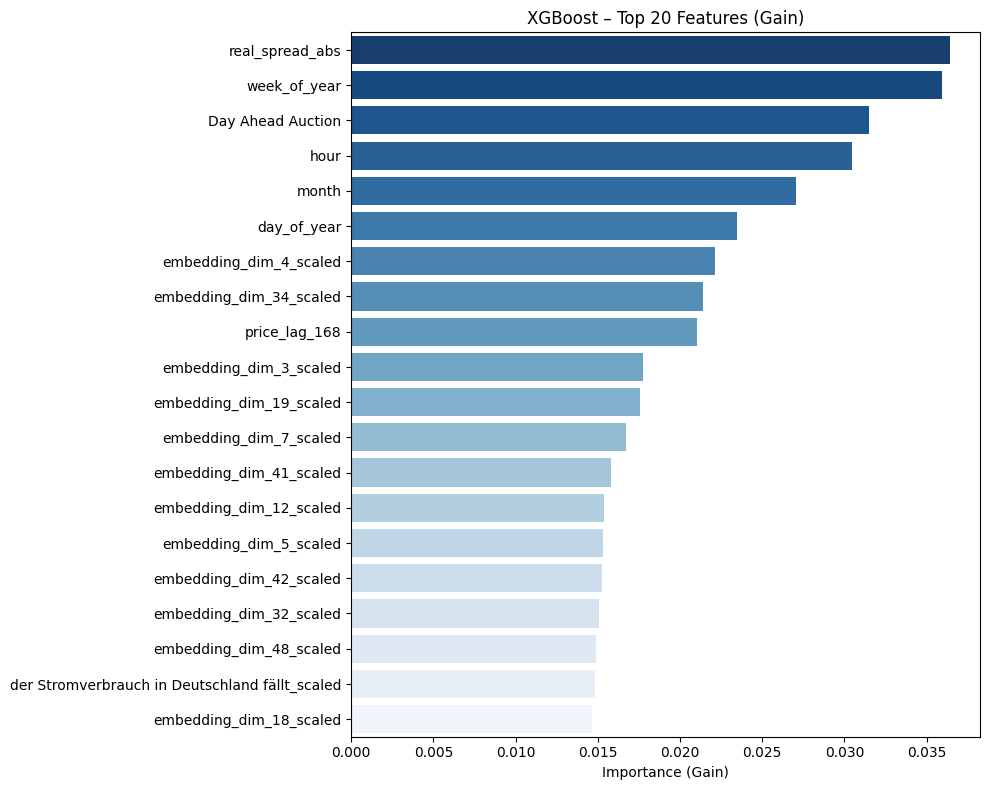

In [17]:
# Feature importance
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 14. Stage 6: LightGBM Signal Modelling


In [18]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")


def _add_xgb_features(frame: pd.DataFrame) -> pd.DataFrame:
    X = frame[best_xgb_feature_columns].fillna(0)
    proba = best_xgb_model.predict_proba(X)
    enriched = frame.copy()
    enriched["xgb_prob_nonpositive"] = proba[:, 0]
    enriched["xgb_prob_positive"] = proba[:, 1]
    enriched["xgb_pred_binary"] = (proba[:, 1] >= 0.5).astype(int)
    return enriched


signal_train_df = _add_xgb_features(best_dataset["train_df"])
signal_val_df = _add_xgb_features(best_dataset["val_df"])
signal_test_df = _add_xgb_features(best_dataset["test_df"])

xgb_feature_names = ["xgb_prob_nonpositive", "xgb_prob_positive", "xgb_pred_binary"]
signal_feature_columns = baseline_features + scaled_news_features + xgb_feature_names
baseline_feature_columns = baseline_features.copy()

print("✓ Prepared LightGBM datasets")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")


✓ Prepared LightGBM datasets
  Signal feature count: 77
  Baseline feature count: 13


In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(signal_train_df[cfg.TARGET_COLUMN].astype(int))

y_train_signal = label_encoder.transform(signal_train_df[cfg.TARGET_COLUMN].astype(int))
y_val_signal = label_encoder.transform(signal_val_df[cfg.TARGET_COLUMN].astype(int))
y_test_signal = label_encoder.transform(signal_test_df[cfg.TARGET_COLUMN].astype(int))

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [20]:
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(
    f"LightGBM device: {lgbm_device_config.get('description')} • "
    f"backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • "
    f"jobs={lgbm_device_config.get('n_jobs')}"
)

train_signal_X = signal_train_df[signal_feature_columns].fillna(0)
base_signal_splitter = model_utils.ExpandingWindowSplitter(
    n_splits=cfg.N_CV_SPLITS,
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)
available_signal_splits = base_signal_splitter.get_n_splits(train_signal_X)
if available_signal_splits == 0:
    raise ValueError("Insufficient data for LightGBM signal cross-validation.")

signal_cv = model_utils.ExpandingWindowSplitter(
    n_splits=min(cfg.N_CV_SPLITS, available_signal_splits),
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)

with profiling.StageProfiler("Stage 6A: LightGBM Signal Model", device_config):
    signal_lgbm_grid = model_utils.run_lgbm_grid_search(
        X_train=train_signal_X,
        y_train=y_train_signal,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        cv=signal_cv,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE,
    )

signal_best_lgbm = signal_lgbm_grid.best_estimator_
print("\n✓ LightGBM signal model trained")
print("  Best params:", signal_lgbm_grid.best_params_)
print(f"  Best CV macro-F1: {signal_lgbm_grid.best_score_:.3f}")


✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
LightGBM device: Apple MPS GPU • backend=cpu • jobs=6

[Stage ⏳] Stage 6A: LightGBM Signal Model — starting
Fitting 5 folds for each of 972 candidates, totalling 4860 fits


[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not support special JSON characters in feature name.
[LightGBM] [Fatal] Do not

[Stage ✅] Stage 6A: LightGBM Signal Model — completed in 5.09s
  CPU usage: 96.6% • IO wait: 0.00%
  Disk Δ: +10.4 MB read, +7.9 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


ValueError: 
All the 4860 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4860 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/lightgbm/engine.py", line 297, in train
    b

In [21]:
train_baseline_X = signal_train_df[baseline_feature_columns].fillna(0)
base_baseline_splitter = model_utils.ExpandingWindowSplitter(
    n_splits=cfg.N_CV_SPLITS,
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)
available_baseline_splits = base_baseline_splitter.get_n_splits(train_baseline_X)
if available_baseline_splits == 0:
    raise ValueError("Insufficient data for LightGBM baseline cross-validation.")

baseline_cv = model_utils.ExpandingWindowSplitter(
    n_splits=min(cfg.N_CV_SPLITS, available_baseline_splits),
    step_size=cfg.DEFAULT_EXPANDING_STEP,
    min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
)

with profiling.StageProfiler("Stage 6B: LightGBM Baseline Model", device_config):
    baseline_lgbm_grid = model_utils.run_lgbm_grid_search(
        X_train=train_baseline_X,
        y_train=y_train_signal,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        cv=baseline_cv,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE,
    )

baseline_best_lgbm = baseline_lgbm_grid.best_estimator_
print("\n✓ LightGBM baseline model trained")
print("  Best params:", baseline_lgbm_grid.best_params_)
print(f"  Best CV macro-F1: {baseline_lgbm_grid.best_score_:.3f}")



[Stage ⏳] Stage 6B: LightGBM Baseline Model — starting
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[Stage ✅] Stage 6B: LightGBM Baseline Model — completed in 75.18s
  CPU usage: 99.9% • IO wait: 0.00%
  Disk Δ: +927.1 MB read, +938.2 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


KeyboardInterrupt: 

In [22]:
from sklearn.metrics import f1_score, accuracy_score

val_signal_X = signal_val_df[signal_feature_columns].fillna(0)
val_baseline_X = signal_val_df[baseline_feature_columns].fillna(0)
test_signal_X = signal_test_df[signal_feature_columns].fillna(0)
test_baseline_X = signal_test_df[baseline_feature_columns].fillna(0)

signal_val_pred = signal_best_lgbm.predict(val_signal_X)
signal_val_proba = signal_best_lgbm.predict_proba(val_signal_X)
signal_test_pred = signal_best_lgbm.predict(test_signal_X)
signal_test_proba = signal_best_lgbm.predict_proba(test_signal_X)

baseline_val_pred = baseline_best_lgbm.predict(val_baseline_X)
baseline_val_proba = baseline_best_lgbm.predict_proba(val_baseline_X)
baseline_test_pred = baseline_best_lgbm.predict(test_baseline_X)
baseline_test_proba = baseline_best_lgbm.predict_proba(test_baseline_X)

val_signal_macro_f1 = f1_score(y_val_signal, signal_val_pred, average="macro", zero_division=0)
val_signal_accuracy = accuracy_score(y_val_signal, signal_val_pred)
val_baseline_macro_f1 = f1_score(y_val_signal, baseline_val_pred, average="macro", zero_division=0)
val_baseline_accuracy = accuracy_score(y_val_signal, baseline_val_pred)

print("✓ LightGBM validation performance")
print(f"  Signal model  → Acc={val_signal_accuracy:.3f}, Macro-F1={val_signal_macro_f1:.3f}")
print(f"  Baseline model → Acc={val_baseline_accuracy:.3f}, Macro-F1={val_baseline_macro_f1:.3f}")


NameError: name 'signal_best_lgbm' is not defined

In [ ]:
lgbm_artifacts = {
    "signal": {
        "model": signal_best_lgbm,
        "feature_columns": signal_feature_columns,
        "train_df": signal_train_df,
        "val_df": signal_val_df,
        "test_df": signal_test_df,
        "val_pred": signal_val_pred,
        "val_proba": signal_val_proba,
        "test_pred": signal_test_pred,
        "test_proba": signal_test_proba,
    },
    "baseline": {
        "model": baseline_best_lgbm,
        "feature_columns": baseline_feature_columns,
        "train_df": signal_train_df,
        "val_df": signal_val_df,
        "test_df": signal_test_df,
        "val_pred": baseline_val_pred,
        "val_proba": baseline_val_proba,
        "test_pred": baseline_test_pred,
        "test_proba": baseline_test_proba,
    },
    "label_encoder": label_encoder,
}

print("✓ Stored LightGBM artifacts for downstream evaluation")


## 15. Stage 7: Evaluation, Visualization & Backtesting


In [ ]:
from sklearn.metrics import classification_report

signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

print("Signal Model Classification Report:")
print(classification_report(y_test_signal, signal_test_pred, target_names=label_encoder.classes_.astype(str)))

print("Baseline Model Classification Report:")
print(classification_report(y_test_signal, baseline_test_pred, target_names=label_encoder.classes_.astype(str)))


In [ ]:
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
statistical_results


In [ ]:
visualization.plot_confusion_matrices(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    class_labels=list(range(len(label_encoder.classes_))),
    label_encoder=label_encoder,
)


In [ ]:
print("LightGBM Signal Feature Importance")
visualization.plot_feature_importance(
    model=signal_best_lgbm,
    feature_names=signal_feature_columns,
    model_name="LightGBM Signal Model",
    top_n=20,
)

print("LightGBM Baseline Feature Importance")
visualization.plot_feature_importance(
    model=baseline_best_lgbm,
    feature_names=baseline_feature_columns,
    model_name="LightGBM Baseline Model",
    top_n=20,
)


In [ ]:
spot_col = evaluation.get_column_name([
    "Spot Price", "spot_price", "SpotPrice"
], signal_test_df)
day_ahead_col = evaluation.get_column_name([
    "Day Ahead Auction", "day_ahead_price", "DayAhead"
], signal_test_df)

if spot_col is None or day_ahead_col is None:
    raise KeyError("Could not identify spot or day-ahead price columns for backtesting.")

spot_series = signal_test_df[spot_col]
day_ahead_series = signal_test_df[day_ahead_col]
spread_series = spot_series - day_ahead_series

strategy_actions = {
    "LightGBM Signal (with news)": signal_test_decoded,
    "LightGBM Baseline (price-only)": baseline_test_decoded,
    "Naive Buy-DA/Sell-Spot": np.ones_like(signal_test_decoded, dtype=int),
}

strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)

display(returns_summary)

visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


## 14. Save Results (Optional)

In [ ]:
# Save model
import joblib
from datetime import datetime

output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = output_dir / f'xgb_model_{timestamp}.joblib'

joblib.dump(best_model, model_path)
print(f"✓ Model saved to: {model_path}")